QUESTION 2: Employee Analytics

In [5]:
import numpy as np
import pandas as pd

In [6]:
# Dataset Creation
np.random.seed(10)
df=pd.DataFrame({"employee_id":range(1,501),
                 "experience_years":np.random.randint(0,20,500),
                 "salary":np.random.randint(20000,150000,500),
                 "performance_rating":np.random.randint(1,6,500),
                 "department":np.random.choice(["IT","HR","Sales","Finance"],500)})

In [7]:
df.head()

,employee_id,experience_years,salary,performance_rating,department
0,1,9,62081,5,Finance
1,2,4,120202,5,IT
2,3,15,109651,3,Finance
3,4,0,70175,2,HR
4,5,17,59493,2,Finance


In [8]:
df.sample(5)

,employee_id,experience_years,salary,performance_rating,department
223,224,17,33563,1,HR
160,161,19,115392,1,Sales
455,456,5,33070,4,HR
251,252,17,41673,4,HR
172,173,5,92229,3,Sales


In [9]:
# Inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         500 non-null    int64 
 1   experience_years    500 non-null    int64 
 2   salary              500 non-null    int64 
 3   performance_rating  500 non-null    int64 
 4   department          500 non-null    object
dtypes: int64(4), object(1)
memory usage: 19.7+ KB


In [10]:
df.describe(include="all")

,employee_id,experience_years,salary,performance_rating,department
count,500.000000,500.000000,500.000000,500.000000,500
unique,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,HR
freq,NaN,NaN,NaN,NaN,128
mean,250.500000,9.768000,85734.504000,2.974000,NaN
std,144.481833,5.896415,37764.998663,1.421748,NaN
min,1.000000,0.000000,20135.000000,1.000000,NaN
25%,125.750000,5.000000,53242.000000,2.000000,NaN
50%,250.500000,10.000000,86474.000000,3.000000,NaN
75%,375.250000,15.000000,118165.250000,4.000000,NaN


In [11]:
# GroupBy with multiple columns
df.groupby("department")["salary"].agg(["mean","median","max",])

,mean,median,max
department,,,
Finance,81765.471074,78103.0,149792
HR,89800.867188,94153.5,149927
IT,85814.166667,79562.5,149722
Sales,85332.272000,87230.0,149897


In [12]:
# Pivot table
pd.pivot_table(df,values="salary",index="department",columns="performance_rating",aggfunc="mean")

performance_rating,1,2,3,4,5
department,,,,,
Finance,82720.923077,76804.807692,83619.500000,82036.041667,84187.920000
HR,97866.692308,90268.281250,85418.960000,79886.210526,92618.461538
IT,90444.909091,79540.033333,91832.444444,79517.652174,88675.583333
Sales,85739.111111,102458.947368,89882.800000,75612.714286,78485.846154


In [13]:
# Ranking
df["salary_rank"]=df["salary"].rank(ascending=False)

In [14]:
df.sample(5)

,employee_id,experience_years,salary,performance_rating,department,salary_rank
34,35,13,106639,2,Sales,177.0
389,390,16,31844,5,Sales,451.0
136,137,13,25735,5,Finance,478.0
276,277,10,96517,1,HR,212.0
35,36,11,106626,3,Sales,178.0


In [15]:
# Conditional column
df["level"]=np.where(df["experience_years"]>=10,"Senior","Junior")
df.sample(5)

,employee_id,experience_years,salary,performance_rating,department,salary_rank,level
367,368,6,138777,4,IT,41.0,Junior
445,446,12,132069,1,HR,69.0,Senior
27,28,13,94355,1,IT,221.0,Senior
97,98,9,62484,1,HR,346.0,Junior
25,26,13,50006,4,Finance,386.0,Senior


In [16]:
# Value counts
df["department"].value_counts(normalize=True)

,proportion
department,
HR,0.256
IT,0.252
Sales,0.250
Finance,0.242


In [17]:
# Visualization
# Salary distribution
import seaborn as sns
import matplotlib.pyplot as plt

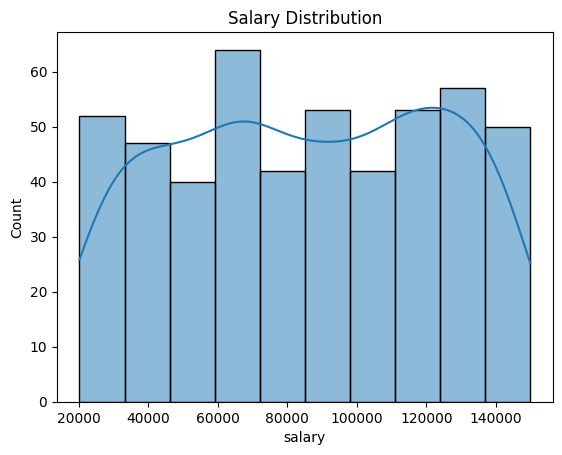

In [22]:
sns.histplot(df["salary"],kde=True)
plt.title("Salary Distribution")
plt.show()

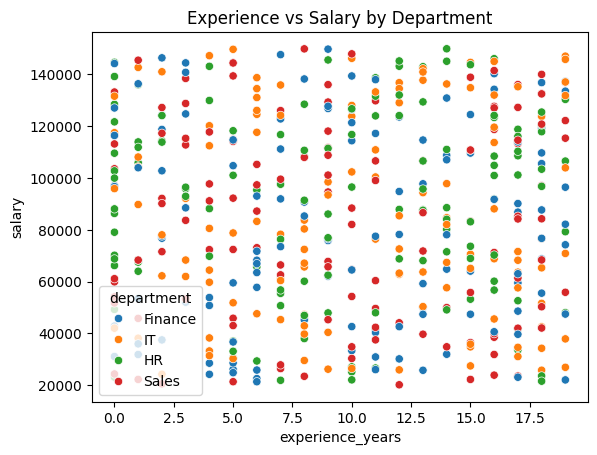

In [28]:
# Experience vs Salary
sns.scatterplot(x="experience_years",y="salary",hue="department",data=df)
plt.title("Experience vs Salary by Department")
plt.show()

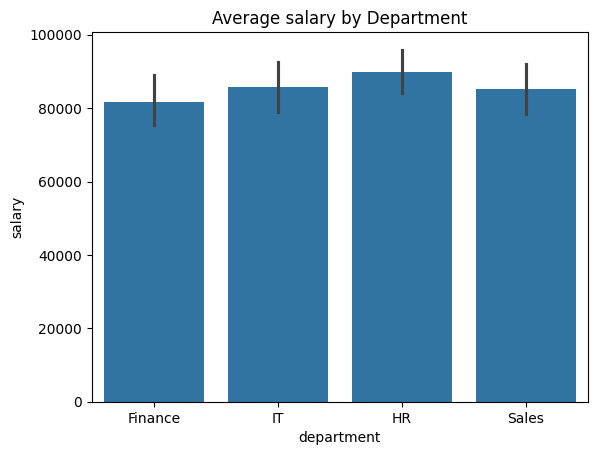

In [26]:
# Bar plot
sns.barplot(x="department",y="salary",data=df)
plt.title("Average salary by Department")
plt.show()

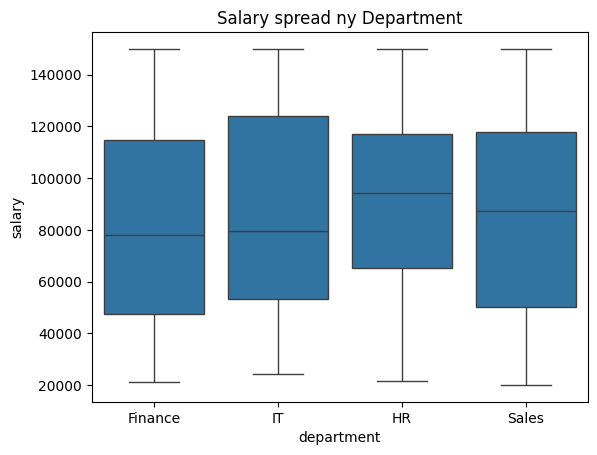

In [30]:
# Boxplot
sns.boxplot(x="department",y="salary",data=df)
plt.title("Salary spread ny Department")
plt.show()